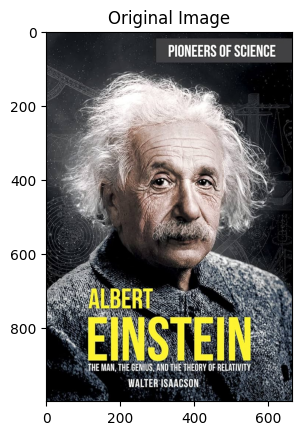

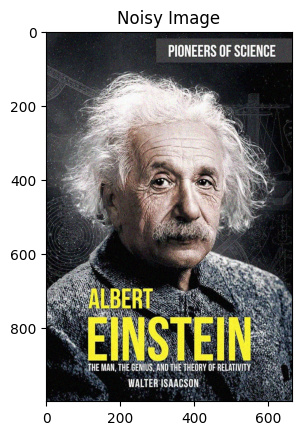

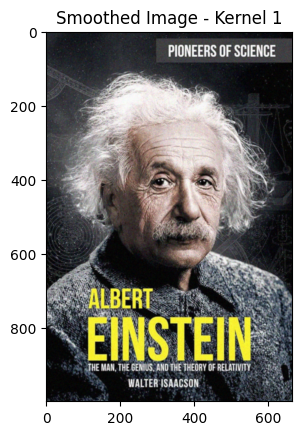

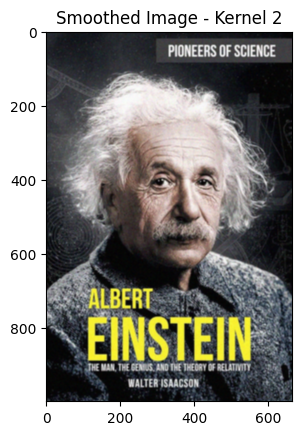

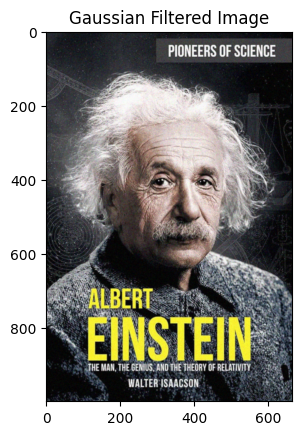

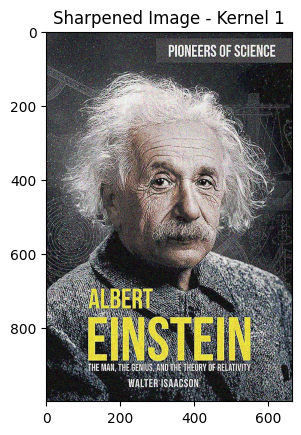

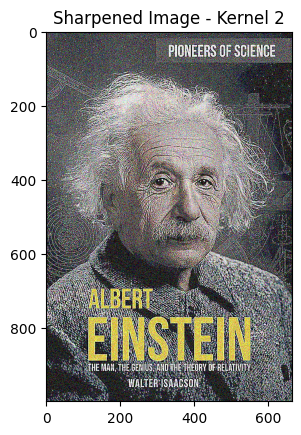

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import convolve2d
import cv2

def load_and_show_image(image_path):
    image = cv2.imread(image_path)
    if image is None:
        print(f"Error: Unable to load image at {image_path}")
        return None
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    plt.imshow(image)
    plt.title("Original Image")
    plt.show()
    return np.double(image)

def add_noise(image):
    noise = 50 * (np.random.rand(*image.shape) - 0.5)
    noisy_image = image + noise
    noisy_image = np.clip(noisy_image, 0, 255)
    plt.imshow(np.uint8(noisy_image))
    plt.title("Noisy Image")
    plt.show()
    return noisy_image

def apply_filter(image, kernel, title):
    filtered_image = np.zeros_like(image)
    for i in range(3):
        filtered_image[:, :, i] = convolve2d(image[:, :, i], kernel, mode='same', boundary='symm')
    filtered_image = np.clip(filtered_image, 0, 255)
    plt.imshow(np.uint8(filtered_image))
    plt.title(title)
    plt.show()
    return filtered_image

# Define filters
kernel_avg1 = np.ones((3, 3)) / 9
kernel_avg2 = np.ones((5, 5)) / 25
kernel_gauss = np.array([[1, 2, 1], [2, 4, 2], [1, 2, 1]]) / 16
kernel_sharp1 = np.array([[0, -1, 0], [-1, 5, -1], [0, -1, 0]])
kernel_sharp2 = np.array([[-1, -1, -1], [-1, 9, -1], [-1, -1, -1]])
kernel_large = np.array([[0, 1, 2, 1, 0], [1, 4, 8, 4, 1], [2, 8, 16, 8, 2], [1, 4, 8, 4, 1], [0, 1, 2, 1, 0]]) / 80
kernel_sobel_x = np.array([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]])
kernel_sobel_y = np.array([[-1, -2, -1], [0, 0, 0], [1, 2, 1]])

def main_project6():
    image_path = "einstein.jpg"
    image = load_and_show_image(image_path)
    if image is None:
        return

    noisy_image = add_noise(image)

    # Apply filters to noisy image
    apply_filter(noisy_image, kernel_avg1, "Smoothed Image - Kernel 1")
    apply_filter(noisy_image, kernel_avg2, "Smoothed Image - Kernel 2")
    apply_filter(noisy_image, kernel_gauss, "Gaussian Filtered Image")
    apply_filter(noisy_image, kernel_sharp1, "Sharpened Image - Kernel 1")
    apply_filter(noisy_image, kernel_sharp2, "Sharpened Image - Kernel 2")
    apply_filter(noisy_image, kernel_large, "Large Kernel Filter")

    # Apply Sobel edge detection filters
    edge_x = apply_filter(image, kernel_sobel_x, "Sobel Edge X")
    edge_y = apply_filter(image, kernel_sobel_y, "Sobel Edge Y")
    combined_edges = edge_x + edge_y

    # Display the combined edge detection result
    plt.imshow(np.uint8(np.clip(combined_edges, 0, 255)), cmap='gray')
    plt.title("Combined Sobel Edge Detection")
    plt.show()

# Run the project
main_project6()
